# GraphSAGE — Inductive Representation Learning on Large Graphs
### Hamilton, Ying, Leskovec — NeurIPS 2017, PPI dataset

This is a walk through of the paper *"Inductive Representation Learning on
Large Graphs"*, together with a **tailored, scaled-down reproduction** of its
PPI (protein-protein interaction) experiment — purpose-built to run
end-to-end on a single local consumer GPU within a strict 2-hour compute
budget, not a claim of the paper's original scale (4× Titan X Pascal GPUs,
three datasets, a full Appendix C hyperparameter sweep). What's reduced is
purely the *experimental budget* (hyperparameter grid size, seed count,
epoch/step counts, described in §7); the algorithm itself — Algorithm 1/2,
the aggregator formulas, the unsupervised loss, the K=2/S1=25/S2=10
architecture — is implemented exactly as the paper specifies, at any scale.

## 1. Introduction and motivation

Classic node-embedding methods (DeepWalk, node2vec, LINE, ...) learn a free
vector per node, optimized directly (one row of an embedding matrix). This
makes them **transductive**: they only work for nodes seen during training,
and generalize poorly to new nodes or new graphs, because the embedding space
can rotate arbitrarily between two training runs.

**GraphSAGE** (*SAmple and aggreGatE*) instead learns a **function** that
generates a node's embedding by aggregating the features of its local
neighborhood, rather than training one embedding per node. Once trained, this
function can be applied to nodes never seen before (**inductive** setting),
and even to entirely new graphs sharing the same feature distribution (as in
the multi-graph PPI case used in this reproduction).

The paper evaluates GraphSAGE on three node-classification tasks on unseen
nodes:
1. **Citation** (Web of Science) — classifying scientific papers,
2. **Reddit** — classifying posts into communities,
3. **PPI** — classifying protein functions on completely different graphs
   between train and test (cross-graph generalization).


## 2. Related work

- **Factorization-based approaches** (DeepWalk, node2vec, LINE, GraRep...):
  directly optimize embeddings via random walks + implicit matrix
  factorization. Inherently transductive.
- **Graph Convolutional Networks (Kipf & Welling, 2016)**: propagate and
  aggregate information across the graph with an approximate spectral
  convolution operator, but in their original formulation require the full
  graph Laplacian and operate in a transductive, fixed-graph setting.
- GraphSAGE **generalizes** the GCN idea into an inductive framework with
  arbitrary trainable aggregators (not just a fixed convolution), and
  introduces neighborhood sampling so the per-batch cost is constant,
  independent of graph size.


## 3. Method — Algorithm 1 (forward propagation)

At each step $k = 1, \dots, K$, every node aggregates the
representations of its neighbors from the previous hop, concatenates them
with its own representation, and transforms the result with a non-linear
dense layer.

**Algorithm 1 — Embedding generation**

$$
\begin{array}{l l l}
\textbf{Input:} & \text{graph } G(V,E) \\
& \text{initial node features } \{x_v : v\in V\} \\
& \text{depth } K \\
& \text{weight matrices } \{\mathbf{W}^k\}_{k=1}^{K} \\
& \text{non-linearity } \sigma \\
& \text{aggregator functions } \{\text{AGGREGATE}_k\}_{k=1}^{K} \\
& \text{neighborhood function } N : v \to 2^V \\[4pt]
\textbf{Output:} & \text{embedding } z_v,\ \forall v \in V \\[8pt]\\[8pt]

1: & h_v^0 \leftarrow x_v, \quad \forall v \in V & \text{start every node from its raw features} \\
2: & \textbf{for } k = 1, \dots, K \textbf{ do} & \\
3: & \quad \textbf{for } v \in V \textbf{ do} & \\
4: & \qquad h_{N(v)}^k \leftarrow \text{AGGREGATE}_k\big(\{h_u^{k-1} : u \in N(v)\}\big) & \text{aggregate sampled neighbors from the previous hop} \\
5: & \qquad h_v^k \leftarrow \sigma\big(\mathbf{W}^k \cdot \text{CONCAT}(h_v^{k-1},\, h_{N(v)}^k)\big) & \text{combine with self, apply a learned transform} \\
6: & \quad \textbf{end} & \\
7: & \quad h_v^k \leftarrow h_v^k \,/\, \lVert h_v^k \rVert_2, \quad \forall v \in V & \text{unit-normalize before the next hop} \\
8: & \textbf{end} & \\
9: & z_v \leftarrow h_v^K, \quad \forall v \in V & \text{final embedding after } K \text{ hops}
\end{array}
$$

Key points:
- $N(v)$ is **not** the full neighborhood, but a fixed-size sample $S$
  re-drawn at every iteration; this makes the per-batch cost
  $O\!\left(\prod_{i=1}^{K} S_i\right)$, independent of $|V|$.
- In this experiment: $K=2$ with $S_1=25$, $S_2=10$.
- Connection to the **Weisfeiler-Lehman** isomorphism test: if $K=|V|$, the
  weights are the identity, and the aggregator is an exact hash function.
  Algorithm 1 becomes exactly the WL test ("naive vertex refinement").
  GraphSAGE is a continuous, trainable approximation of this test.


### 3.1 Sample → Aggregate → Predict

Algorithm 1's forward pass, plus the unsupervised objective that trains it, 
breaks down into exactly the three steps.

1. **Sample neighborhood**: 
   draw a fixed-size sample of $v$'s 1-hop
   neighbors ($S_1$), then a fixed-size sample of *their* neighbors in turn
   ($S_2$). Arrows point **outward**, in the order the sampling walks.
2. **Aggregate feature information from neighbors**:
   $\text{AGGREGATE}_k$ combines each sampled node's previous-hop representation into its parent,
   hop by hop (line 4), then CONCAT + $\sigma(\mathbf{W}^k\cdot)$ folds in the
   node's own representation (line 5). Arrows now point **inward**, so the
   reverse of step 1.
3. **Predict graph context**: 
   once Algorithm 1 produces embeddings, the
   unsupervised objective (Eq. 1, Section 5) pulls a target's embedding
   toward a positive context node found via a random walk, and pushes it
   away from negative samples drawn from the degree-based unigram
   distribution.

See Section 5 for the full objective, and Section 6 for how the four
aggregator variants implement step 2 differently.


![The GraphSAGE forward pass, step by step: sample neighborhood, aggregate feature information, predict graph context](illustrations/pipeline_illustration.png)

*Static illustration on a synthetic 18-node graph (not PPI data). Purely didactic, not part of the reproduction pipeline; see illustrations/README.md.*

## 4. Algorithm 2 — minibatch forward propagation

For SGD training, the paper first samples the set of nodes that will be
needed (working backwards, from $\mathcal{B}^K$ = the target minibatch down
to $\mathcal{B}^0$ = the leaf nodes with only raw features), then runs the
aggregation forward:

$$
\begin{array}{l l l}
\textbf{Input:} & \text{graph } G(V,E) \\
& \text{input features } \{x_v : v\in B\} \\
& \text{depth } K \\
& \text{weight matrices } \{\mathbf{W}^k\}_{k=1}^{K} \\
& \text{non-linearity } \sigma \\
& \text{aggregator functions } \{\text{AGGREGATE}_k\}_{k=1}^{K} \\
& \text{neighborhood sampling functions } \{N_k : v \to 2^V\}_{k=1}^{K} \\[4pt]
\textbf{Output:} & \text{embedding } z_u,\ \forall u \in B \\[8pt]\\[8pt]
1: & B^K \leftarrow B & \text{start from the target minibatch} \\
2: & \textbf{for } k = K, \dots, 1 \textbf{ do} & \text{expand outward, hop by hop} \\
3: & \quad B^{k-1} \leftarrow B^k & \\
4: & \quad \textbf{for } u \in B^k \textbf{ do} & \\
5: & \qquad B^{k-1} \leftarrow B^{k-1} \cup N_k(u) & \text{add } u\text{'s sampled neighbors} \\
6: & \quad \textbf{end} & \\
7: & \textbf{end} & \\
8: & h_u^0 \leftarrow x_u, \quad \forall u \in B^0 & \text{leaf nodes start from raw features} \\
9: & \textbf{for } k = 1, \dots, K \textbf{ do} & \text{now aggregate back inward} \\
10: & \quad \textbf{for } u \in B^k \textbf{ do} & \\
11: & \qquad h_{N(u)}^k \leftarrow \text{AGGREGATE}_k\big(\{h_{u'}^{k-1} : u' \in N_k(u)\}\big) & \text{aggregate sampled neighbors} \\
12: & \qquad h_u^k \leftarrow \sigma\big(\mathbf{W}^k \cdot \text{CONCAT}(h_u^{k-1},\, h_{N(u)}^k)\big) & \text{combine with self, apply a learned transform} \\
13: & \quad \textbf{end} & \\
14: & \quad h_u^k \leftarrow h_u^k \,/\, \lVert h_u^k \rVert_2, \quad \forall u \in B^k & \text{unit-normalize before the next hop} \\
15: & \textbf{end} & \\
16: & z_u \leftarrow h_u^K, \quad \forall u \in B & \text{final embedding after } K \text{ hops}
\end{array}
$$

Counter-intuitive note: with $K=2$, $S_1=25$, $S_2=10$, the backward
sampling in lines 1-7 means that $S_2=10$ direct neighbors and
$S_1 \cdot S_2 = 250$ 2-hop neighbors are sampled per target node — the
indices $1,2$ refer to the iteration order of Algorithm 1's hops, not the
distance from the target node.


## 5. Objective function

**Unsupervised** — encourages nodes that co-occur on a
random walk to have similar representations, and distant nodes (sampled as
negatives) to have distinct representations:

$$J_{\mathcal G}(z_u) = -\log\big(\sigma(z_u^\top z_v)\big) - Q \cdot \mathbb{E}_{v_n \sim P_n(v)}\log\big(\sigma(-z_u^\top z_{v_n})\big)$$

where $v$ co-occurs with $u$ on a fixed-length random walk, $\sigma$ is the
sigmoid, $P_n$ is the negative-sampling distribution, and
$z_u, z_v$ are generated by Algorithm 1/2, **not** looked up from a table.

**Supervised**: the unsupervised loss is replaced or complemented by a
cross-entropy on the downstream task. For PPI, which is **multi-label**
(every protein can have several GO functions at once, out of 121 possible),
a per-class sigmoid cross-entropy is used instead of multi-class softmax
(`--sigmoid true` flag in `supervised_train.py`).


## 6. Aggregator architectures

The paper compares four aggregators:

**Mean aggregator / GraphSAGE-GCN.** Elementwise average of the neighbors.
The "convolutional" variant (used for `GraphSAGE-GCN`) does *not* concatenate
the node's own representation with the neighborhood one (no skip
connection):

$$h_v^k \leftarrow \sigma\Big(\mathbf{W}\cdot \text{MEAN}\big(\{h_v^{k-1}\}\cup\{h_u^{k-1}, \forall u\in N(v)\}\big)\Big)$$

This is a linear approximation of Kipf & Welling's localized spectral
convolution, adapted to the inductive setting.

**LSTM aggregator.** Applies an LSTM to the neighbors in random order (a
fresh random permutation per batch) — not permutation-invariant in principle,
but empirically works very well (Section 4.4 of the paper).

**Pooling aggregator** (`GraphSAGE-pool`, max-pooling). Each neighbor is
passed through a shared MLP, then an elementwise max is applied:

$$\text{AGGREGATE}_k^{pool} = \max\Big(\big\{\sigma(\mathbf{W}_{pool}\, h_{u_i}^k + b),\ \forall u_i \in N(v)\big\}\Big)$$

The paper notes no significant difference between max- and mean-pooling, and
uses max-pooling as the official "pool" aggregator in Table 1.


### 6.1 Visualizing the four aggregators

Same self/neighbor inputs, four different ways of turning them into the next
layer's representation -- drawn as small node-and-edge graphs (echoing
Section 3.1's style) rather than abstract boxes, so the *shape* of each
operation is visible: neighbor colors blending together for mean, self
folded directly into that same blend for GCN (no separate branch), only the
arg-max neighbor surviving for pool, and a shuffled left-to-right chain for
LSTM. Colors here match the ones used consistently for these four variants
throughout the rest of this notebook (results tables, loss curves, etc.).

![The four aggregator architectures compared: mean, GCN, pooling, LSTM](illustrations/aggregator_architectures.png)

*Static illustration of the four AGGREGATE_k operations. Purely didactic, not part of the reproduction pipeline; see illustrations/README.md.*

## 7. Experimental setup of this reproduction

- **Dataset**: **PPI only** (public at http://snap.stanford.edu/graphsage/).
  24 graphs (20 train / 2 val / 2 test), features
  = positional/motif gene sets + immunological signatures, labels = 121 gene
  ontology terms (multi-label).
- **Baselines**: Random (Bernoulli draws at the train positive rate) and Raw
  features (`OneVsRestClassifier(SGDClassifier(loss="log"))`) — implemented in `scripts/baseline_ppi.py`.
- **GraphSAGE**: 4 aggregators (`graphsage_mean`, `gcn`, `graphsage_seq` i.e.
  LSTM, `graphsage_maxpool` i.e. pool) × {supervised, unsupervised} = 8
  variants, each with $K=2$, $S_1=25$, $S_2=10$, hidden dimension 128
  (×2 if concatenated), batch size 512, 20 negative samples — this
  architecture is not reduced anywhere in this repo.
- **Hyperparameter selection**: Appendix C's real procedure sweeps learning
  rate (3 values per setting) × model size (small/big) and keeps whichever
  of the 6 candidates per variant scores best *on validation*.
  `scripts/run_ppi_experiments_scaled.py` — this repo's actual pipeline —
  runs a **2-value learning-rate grid, "small" size only**, supervised
  candidates at the full 10 epochs, unsupervised candidates capped at
  **3000 of the normal 17,050 steps/epoch** — a cutoff justified by §8.2
  below's own finding that embedding structure is "largely in place by step
  200". All four tiers (sweep, +1 seed, sensitivity sweep, noise-robustness)
  together took **75.3 minutes** (73.1 for the original full run, plus 2.2
  for the neighborhood-sample-size half of the sensitivity sweep, added in a
  later pass), logged in full in `results/scaled_run_manifest.json`.
  See README.md's "Scaled local reproduction" section for the complete
  breakdown and an important caveat: the multi-seed and K=2 comparisons
  below each reuse one genuine full-10-epoch point alongside
  freshly-trained reduced-epoch ones, so treat those specific comparisons
  as suggestive rather than perfectly controlled.
- For the unsupervised variants, the resulting embeddings are then evaluated
  by training a logistic regression classifier **only on the training
  nodes** and evaluating on the held-out split (`scripts/eval_unsupervised.py
  --split test` for the reported number; `--split val` is what the sweep uses
  to select a config, never test performance).


## 8. Results

The cells below load the results produced by the individual training/eval
runs (baselines in `results/baseline_ppi.json`, supervised F1 in
`logs/sup-ppi/<model>_small_0.0100/test_stats.txt`, unsupervised F1 in
`results/eval_unsup_<model>.json`) and compare them against the PPI columns
of Table 1 in the paper.


In [1]:
import json, os, re, sys
import numpy as np
import pandas as pd

REPO = os.path.abspath(os.path.join(os.getcwd()))
LOGS = os.path.join(REPO, "logs")
RESULTS = os.path.join(REPO, "results")

sys.path.insert(0, REPO)
import plotting

MODELS = [
    ("graphsage_mean", "GraphSAGE-mean"),
    ("gcn", "GraphSAGE-GCN"),
    ("graphsage_seq", "GraphSAGE-LSTM"),
    ("graphsage_maxpool", "GraphSAGE-pool"),
]

PAPER = {
    "Random": (0.396, 0.396),
    "Raw features": (0.422, 0.422),
    "GraphSAGE-GCN": (0.465, 0.500),
    "GraphSAGE-mean": (0.486, 0.598),
    "GraphSAGE-LSTM": (0.482, 0.612),
    "GraphSAGE-pool": (0.502, 0.600),
}

# If scripts/sweep_ppi_experiments.py has been run, results/best_hparams_ppi.json
# records the (learning_rate, model_size) Appendix C selected on *validation*
# performance for each variant -- use that run's directory instead of assuming
# the single default config ("<model>_small_0.0100"). A variant absent from the
# manifest (partial sweep, or no sweep run at all) falls back to the default
# path, exactly like scripts/compile_results.py.
best_hparams_path = os.path.join(RESULTS, "best_hparams_ppi.json")
best_hparams = {}
if os.path.exists(best_hparams_path):
    with open(best_hparams_path) as fp:
        best_hparams = json.load(fp)

def parse_test_stats(path):
    with open(path) as fp:
        content = fp.read()
    m = re.search(r"f1_micro=([\d.]+)", content)
    return float(m.group(1)) if m else None

with open(os.path.join(RESULTS, "baseline_ppi.json")) as fp:
    baseline = json.load(fp)

rows = []
rows.append(["Random", baseline["random"]["f1_micro"], baseline["random"]["f1_micro"],
             *PAPER["Random"], "n/a"])
rows.append(["Raw features", baseline["raw_features"]["f1_micro"], baseline["raw_features"]["f1_micro"],
             *PAPER["Raw features"], "n/a"])

for model_flag, display_name in MODELS:
    model_manifest = best_hparams.get(model_flag, {})

    # Unsupervised: sweep_ppi_experiments.py overwrites this exact path with
    # the validation-selected winner's *test* score, so it's already correct
    # whether or not a sweep has been run.
    with open(os.path.join(RESULTS, f"eval_unsup_{model_flag}.json")) as fp:
        unsup_f1 = json.load(fp)["f1_micro"]

    # Supervised: each sweep candidate gets its own log directory, so the
    # winner has to be looked up via the manifest.
    sup_entry = model_manifest.get("supervised")
    if sup_entry is not None:
        sup_dir = f"{model_flag}_{sup_entry['model_size']}_{sup_entry['learning_rate']:0.4f}"
    else:
        sup_dir = f"{model_flag}_small_0.0100"
    sup_f1 = parse_test_stats(os.path.join(LOGS, "sup-ppi", sup_dir, "test_stats.txt"))

    swept = (sup_entry is not None) or ("unsupervised" in model_manifest)
    rows.append([display_name, unsup_f1, sup_f1, *PAPER[display_name],
                 "Appendix C sweep" if swept else "single default run"])

df = pd.DataFrame(rows, columns=["Name", "Unsup. F1 (reproduced)", "Sup. F1 (reproduced)",
                                   "Unsup. F1 (paper)", "Sup. F1 (paper)", "Selection"])
df[["Unsup. F1 (reproduced)", "Sup. F1 (reproduced)", "Unsup. F1 (paper)", "Sup. F1 (paper)"]] = \
    df[["Unsup. F1 (reproduced)", "Sup. F1 (reproduced)", "Unsup. F1 (paper)", "Sup. F1 (paper)"]].round(3)
df

,Name,Unsup. F1 (reproduced),Sup. F1 (reproduced),Unsup. F1 (paper),Sup. F1 (paper),Selection
0,Random,0.398,0.398,0.396,0.396,n/a
1,Raw features,0.432,0.432,0.422,0.422,n/a
2,GraphSAGE-mean,0.464,0.585,0.486,0.598,Appendix C sweep
3,GraphSAGE-GCN,0.473,0.521,0.465,0.500,Appendix C sweep
4,GraphSAGE-LSTM,0.439,0.599,0.482,0.612,Appendix C sweep
5,GraphSAGE-pool,0.466,0.602,0.502,0.600,Appendix C sweep


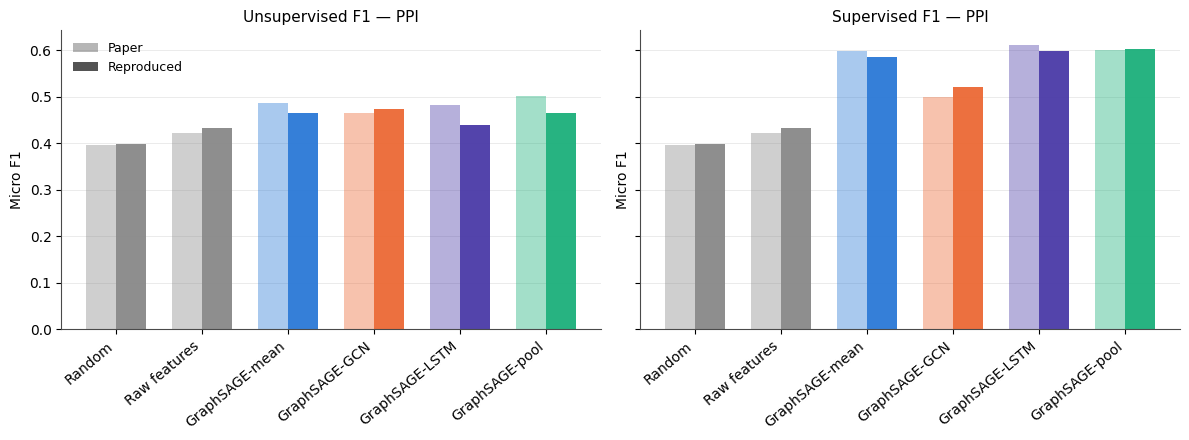

In [2]:
plotting.plot_f1_comparison(df, save_path=os.path.join(RESULTS, "ppi_comparison.png"));

### Training time per variant

In [3]:
timing_rows = []
for model_flag, display_name in MODELS:
    sup_time = plotting.extract_last_avg_time(os.path.join(LOGS, f"sup_{model_flag}.log"))
    unsup_time = plotting.extract_last_avg_time(os.path.join(LOGS, f"unsup_{model_flag}.log"))
    timing_rows.append([display_name, sup_time, unsup_time])

timing_df = pd.DataFrame(timing_rows, columns=["Name", "Sup. sec/iter", "Unsup. sec/iter"])
timing_df

,Name,Sup. sec/iter,Unsup. sec/iter
0,GraphSAGE-mean,0.38300,0.01099
1,GraphSAGE-GCN,0.38699,0.01152
2,GraphSAGE-LSTM,0.78941,0.15549
3,GraphSAGE-pool,0.42576,0.05348


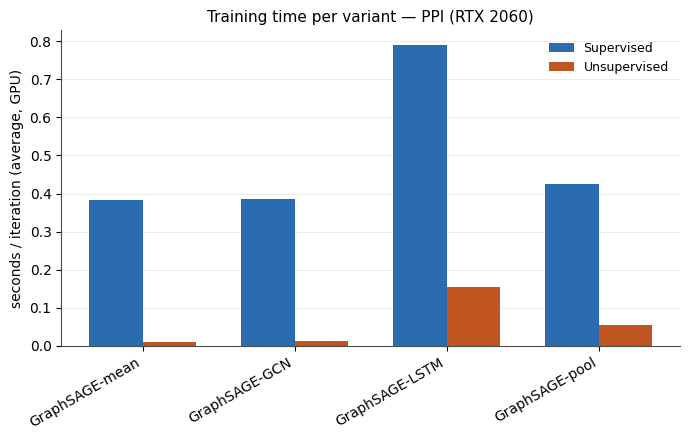

In [4]:
plotting.plot_timing(timing_df, save_path=os.path.join(RESULTS, "ppi_timing.png"));

### 8.1 Training dynamics: loss and task performance

Training loss is logged at every step (`--print_every 5`, into each run's
`metrics.csv`) but only *re-evaluates* on a validation sample every
`--validate_iter` steps (5000 by default) -- since one PPI epoch is much
shorter than that, in practice validation only refreshes once per epoch,
while the training loss is visible at a much finer grain in between.
Plotting both against the same step axis: a noisy, high-frequency training
curve against a coarse, "staircase" validation curve -- i.e. literally what
the optimizer's gradient steps are doing *between* the evaluations that
report it.

Loss is a training-optimization proxy, not the number Table 1 (or this
notebook's own results table above) actually reports -- so a second sheet
right after it plots the metric each setting is actually judged on instead:
F1 (micro) for supervised, MRR for unsupervised, from the same
`metrics.csv` files.

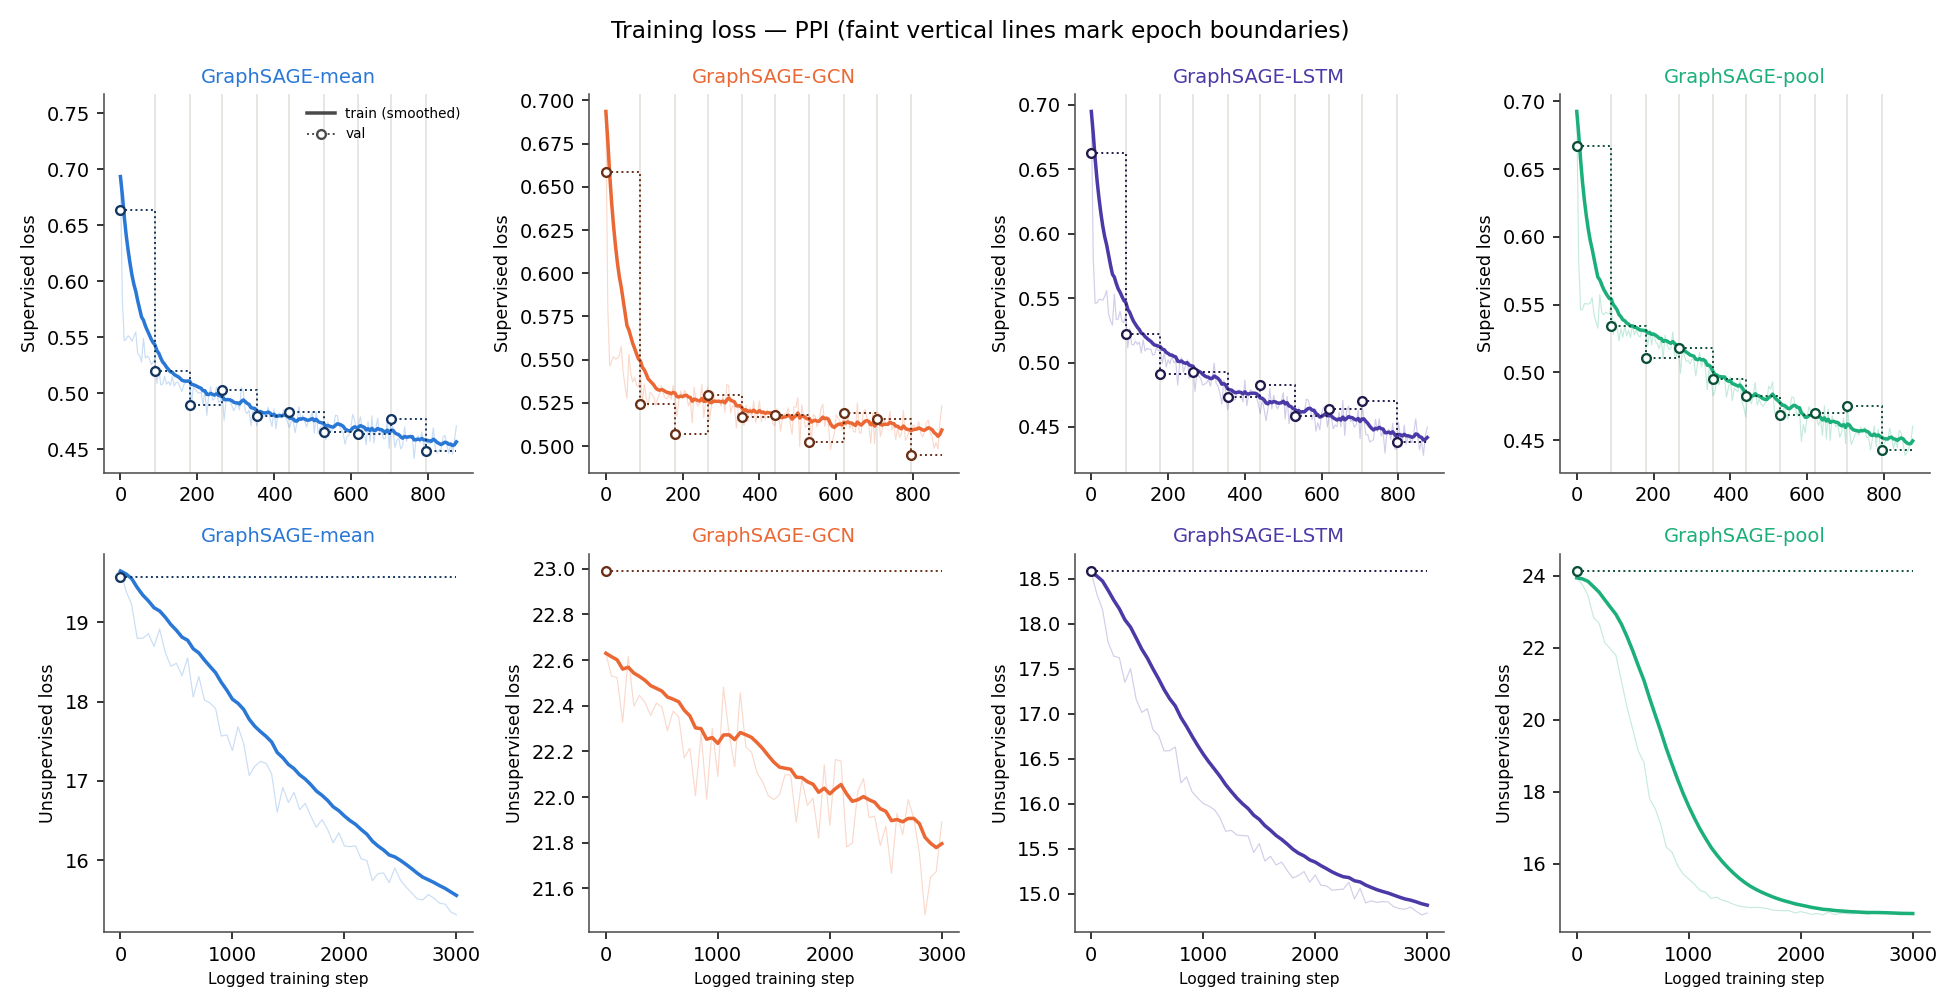

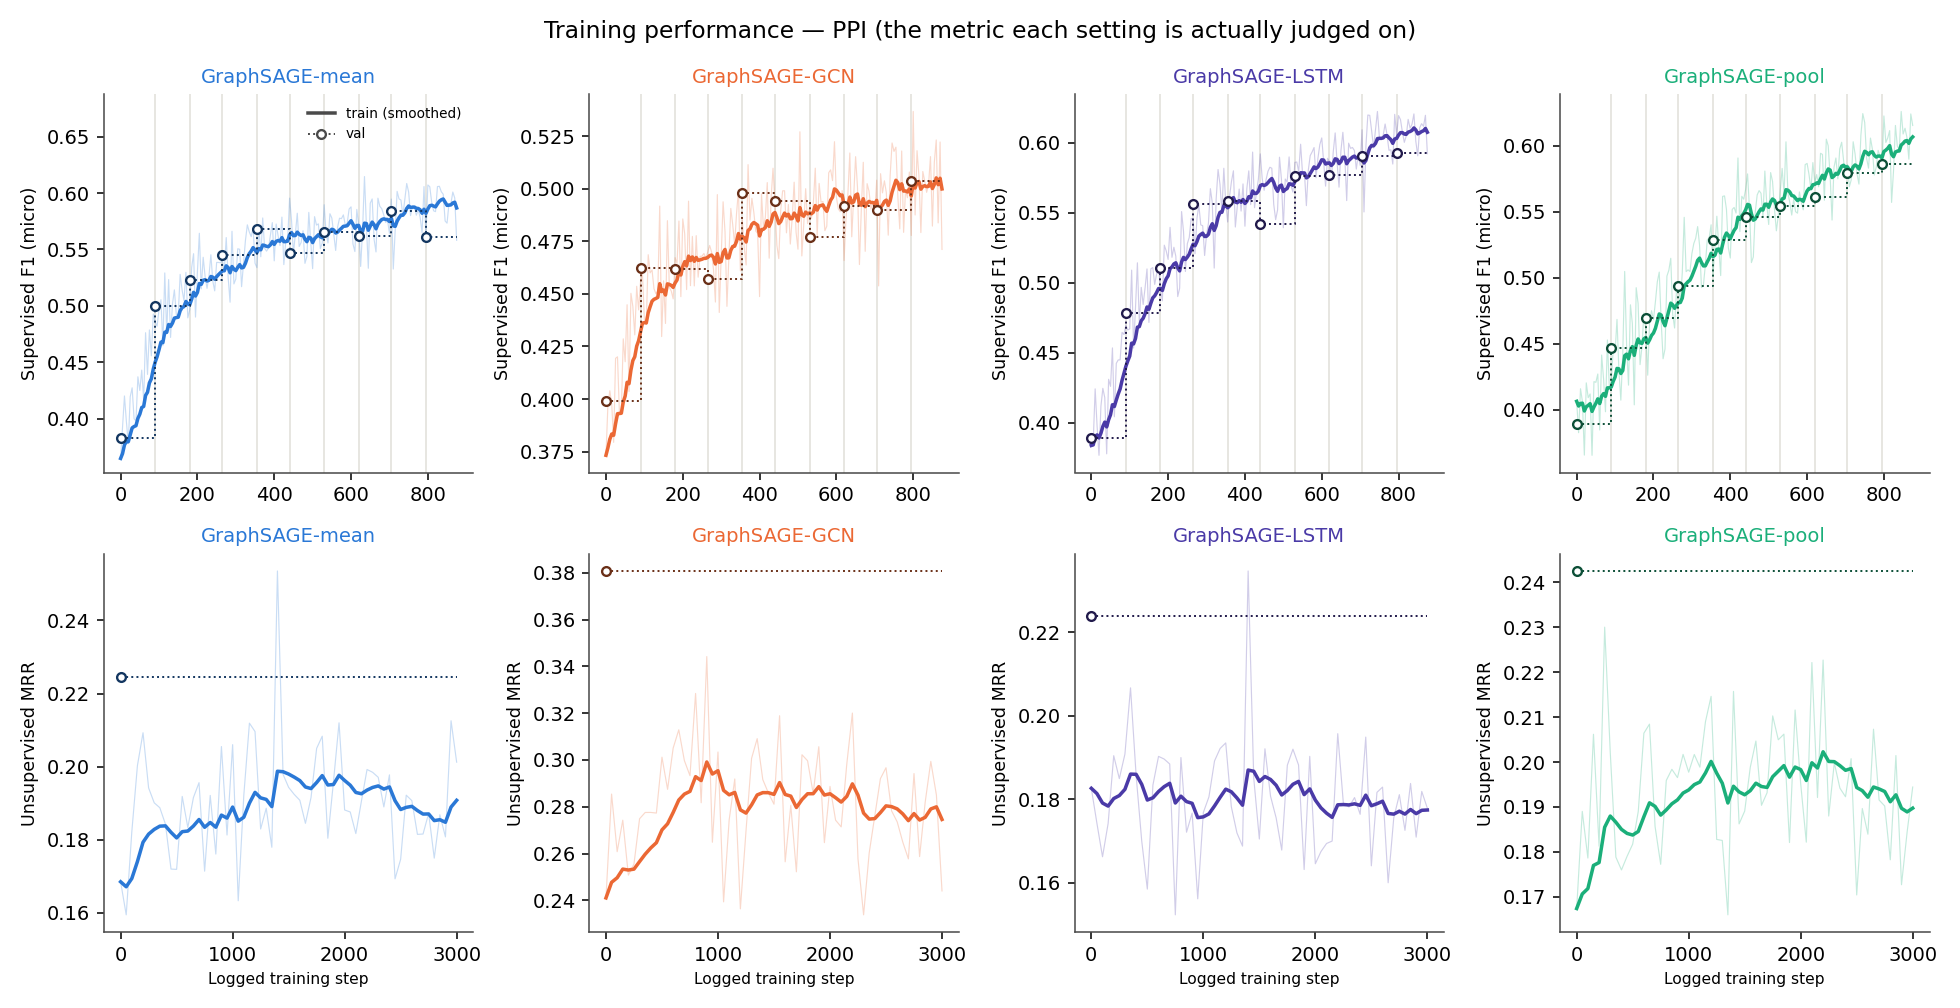

In [5]:
# Resolve each model's actual log directory -- the Appendix-C-sweep-selected
# hyperparameters when results/best_hparams_ppi.json has an entry (same
# logic the results table above uses), else the code's own defaults -- so
# the charts below read the metrics.csv that was actually produced for the
# config this repo reports, not always the raw code defaults.
DEFAULT_UNSUP_LR = 0.00001

def sup_log_dir_path(model_flag):
    entry = best_hparams.get(model_flag, {}).get("supervised")
    tag = (f"{model_flag}_{entry['model_size']}_{entry['learning_rate']:0.4f}"
           if entry else f"{model_flag}_small_0.0100")
    return os.path.join(LOGS, "sup-ppi", tag)

def unsup_log_dir_path(model_flag):
    entry = best_hparams.get(model_flag, {}).get("unsupervised")
    lr = entry["learning_rate"] if entry else DEFAULT_UNSUP_LR
    size = entry["model_size"] if entry else "small"
    return os.path.join(LOGS, "unsup-ppi", f"{model_flag}_{size}_{format(lr, '.2e')}")

sup_log_dirs = {flag: sup_log_dir_path(flag) for flag, _ in MODELS}
unsup_log_dirs = {flag: unsup_log_dir_path(flag) for flag, _ in MODELS}

plotting.plot_loss_curves(
    sup_log_dirs, unsup_log_dirs, MODELS,
    save_path=os.path.join(RESULTS, "ppi_loss_curves.png"));
plotting.plot_performance_curves(
    sup_log_dirs, unsup_log_dirs, MODELS,
    save_path=os.path.join(RESULTS, "ppi_performance_curves.png"));

### 8.2 Watching the embedding space train: phases of aggregation

Rather than looking only at the final, fully-trained embeddings, this
section tracks how they get there. `unsupervised_train.py` takes an
`--embedding_snapshot_steps` flag (empty by default, so a normal run is
unaffected) that dumps embeddings for every node at the given training steps
*during* its regular, single continuous run -- same seeds, same minibatch
order as the reproduction above, no separate or duplicate training required.
The flag is generic (any aggregator can use it), so
`scripts/run_ppi_experiments.py` passes it to all four unsupervised runs,
each producing 7 snapshots along the way: right after initialization (step
0), and after 100, 200, 800, 3,000, 8,000 and 17,050 (~1 full epoch)
gradient steps. Because each is one uninterrupted run, these are genuine
snapshots of a single trajectory, not independent restarts.

Pick which aggregator to look at with `EMBED_MODEL` below -- it works for
any of the four (`graphsage_mean`, `gcn`, `graphsage_seq`,
`graphsage_maxpool`) as long as that variant was run with the snapshot flag;
it defaults to the best unsupervised performer from the results table above.

To make the stages visually comparable, a **fixed subsample of ~1,000 nodes**
(stratified by split) is tracked through every stage, and each projection
method below is fit **once**, on the fully-trained (final) stage for PCA,
jointly across all stages at once for t-SNE, so that a point's position
means the same thing in every panel, and its movement across panels is
directly readable rather than an artifact of re-fitting the projection each
time.

Each projection sheet ends with one more panel: the final stage colored by
node degree instead of split -- Theorem 1 (Appendix E) is specifically
about the pooling aggregator exploiting *structural* signal, so this is the
most direct check of that claim available from data already collected here.

In [6]:
import sys

sys.path.insert(0, os.path.join(REPO, "src"))
from graphsage.utils import load_data

# Pick which aggregator's training progression to plot -- any of the four
# MODELS work here as long as that variant was run with
# --embedding_snapshot_steps (scripts/run_ppi_experiments.py passes it to
# all four). Change this to compare a different aggregator's progression.
EMBED_MODEL = "graphsage_maxpool"  # our strongest unsupervised variant (see table above)

# Embedding snapshots are only ever produced by run_ppi_experiments.py's
# single default-hyperparameter run (scripts/sweep_ppi_experiments.py
# deliberately skips them for its sweep candidates -- see that script's
# docstring), so this always looks under the *default* run's directory,
# tagged "small_1.00e-05" -- matching unsupervised_train.py's log_dir()
# scientific-notation formatting (not fixed-point: at 6 decimal places,
# Appendix C's smaller sweep learning rates like 2e-7/2e-8 would collide).
UNSUP_DEFAULT_TAG = "small_%s" % format(0.00001, ".2e")

SNAPSHOT_STEPS = [0, 100, 200, 800, 3000, 8000, 17050]
snapshot_root = os.path.join(LOGS, "unsup-ppi", f"{EMBED_MODEL}_{UNSUP_DEFAULT_TAG}", "snapshots")

available_snapshots = {
    flag: os.path.isdir(os.path.join(LOGS, "unsup-ppi", f"{flag}_{UNSUP_DEFAULT_TAG}", "snapshots"))
    for flag, _ in MODELS
}
print("Aggregators with snapshot data available:", [f for f, ok in available_snapshots.items() if ok] or "none")
if not available_snapshots.get(EMBED_MODEL, False):
    raise FileNotFoundError(
        f"No snapshots found for '{EMBED_MODEL}'. Rerun it with --embedding_snapshot_steps "
        "(see scripts/run_ppi_experiments.py), or set EMBED_MODEL above to one of the "
        "aggregators listed as available."
    )

EMBED_MODEL_NAME = dict(MODELS)[EMBED_MODEL]  # display name, e.g. "GraphSAGE-pool", used in titles below

split_colors = {"train": "#2a78d6", "val": "#eda100", "test": "#e34948"}


def load_snapshot(step):
    d = os.path.join(snapshot_root, "step_%05d" % step)
    emb = np.load(os.path.join(d, "val.npy"))
    with open(os.path.join(d, "val.txt")) as fp:
        ids = [int(line.strip()) for line in fp if line.strip()]
    return emb, {node_id: row for row, node_id in enumerate(ids)}


G, _, _, _, _ = load_data("data/ppi/ppi", load_walks=False)

# node ids present in every snapshot (all of them, in practice -- every
# snapshot covers all 56,944 nodes -- but this keeps things robust)
_, final_id_to_row = load_snapshot(SNAPSHOT_STEPS[-1])
node_list = [n for n in G.nodes() if n in final_id_to_row]
node_split = np.array(["test" if G.node[n]["test"] else ("val" if G.node[n]["val"] else "train") for n in node_list])
node_degree = np.array([G.degree(n) for n in node_list])

# one fixed, stratified-by-split subsample, shared by every stage and both
# projection methods below (so "the same nodes" are being tracked throughout)
n_sub = 1000
rng_sub = np.random.RandomState(123)
sub_mask = np.zeros(len(node_list), dtype=bool)
for split_name in split_colors:
    idx = np.where(node_split == split_name)[0]
    take = max(1, int(round(n_sub * len(idx) / len(node_list))))
    sub_mask[rng_sub.choice(idx, size=min(take, len(idx)), replace=False)] = True

sub_ids = [node_list[i] for i in range(len(node_list)) if sub_mask[i]]
sub_split = node_split[sub_mask]
sub_degree = node_degree[sub_mask]

snapshot_embeddings = {}
for step in SNAPSHOT_STEPS:
    emb, id_to_row = load_snapshot(step)
    snapshot_embeddings[step] = emb[[id_to_row[nid] for nid in sub_ids]]

print(f"Tracking {len(sub_ids)} nodes ({(sub_split=='train').sum()} train / "
      f"{(sub_split=='val').sum()} val / {(sub_split=='test').sum()} test) "
      f"across {len(SNAPSHOT_STEPS)} training snapshots")

Aggregators with snapshot data available: ['graphsage_mean', 'gcn', 'graphsage_seq', 'graphsage_maxpool']


Removed 0 nodes that lacked proper annotations due to networkx versioning issues
Loaded data.. now preprocessing..


Tracking 1000 nodes (789 train / 114 val / 97 test) across 7 training snapshots


**PCA view.** The projection is fit once, on the final (step 17,050)
stage, and every earlier stage is transformed into that *same* space.


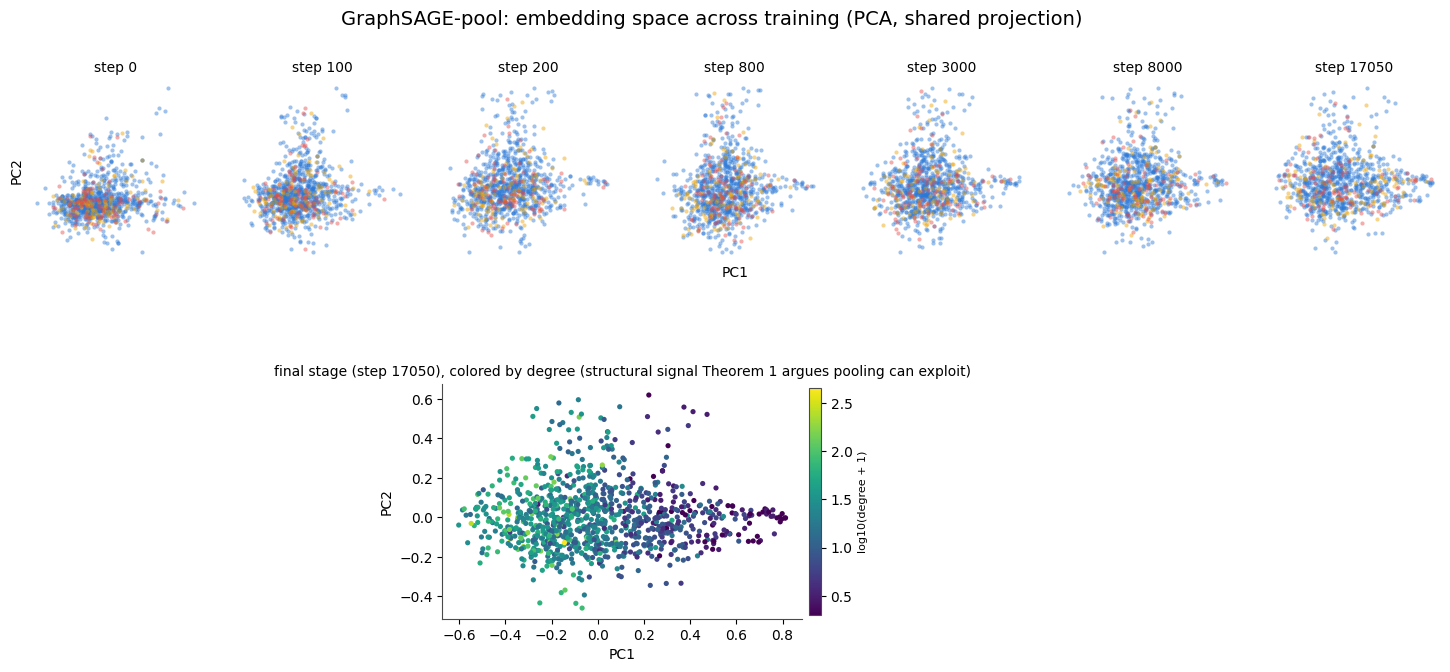

In [7]:
from sklearn.decomposition import PCA

pca_shared = PCA(n_components=2, random_state=123)
pca_shared.fit(snapshot_embeddings[SNAPSHOT_STEPS[-1]])
pca_coords = {step: pca_shared.transform(snapshot_embeddings[step]) for step in SNAPSHOT_STEPS}

plotting.plot_stage_sheet(
    pca_coords, SNAPSHOT_STEPS, split_colors, sub_split,
    f"{EMBED_MODEL_NAME}: embedding space across training (PCA, shared projection)", "PC1", "PC2",
    sub_degree=sub_degree,
    save_path=os.path.join(RESULTS, "ppi_embedding_pca.png"));

**t-SNE view.** t-SNE has no simple out-of-sample "transform" for new
points, so to get one shared space across stages we fit it **jointly**: all
7 stages' embeddings for the same subsample are stacked into one matrix,
t-SNE is run once on the stack, and the result is split back out per stage.
It captures non-linear cluster structure that PCA can't.

c:\users\feder\appdata\local\programs\python\python38\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Impossibile trovare il file specificato
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\users\feder\appdata\local\programs\python\python38\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\users\feder\appdata\local\programs\python\python38\lib\subprocess.py", line 489, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\users\feder\appdata\local\programs\python\python38\lib\subprocess.py", line 854, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\users\feder\appdata\local\programs\python\python38\lib\subprocess.

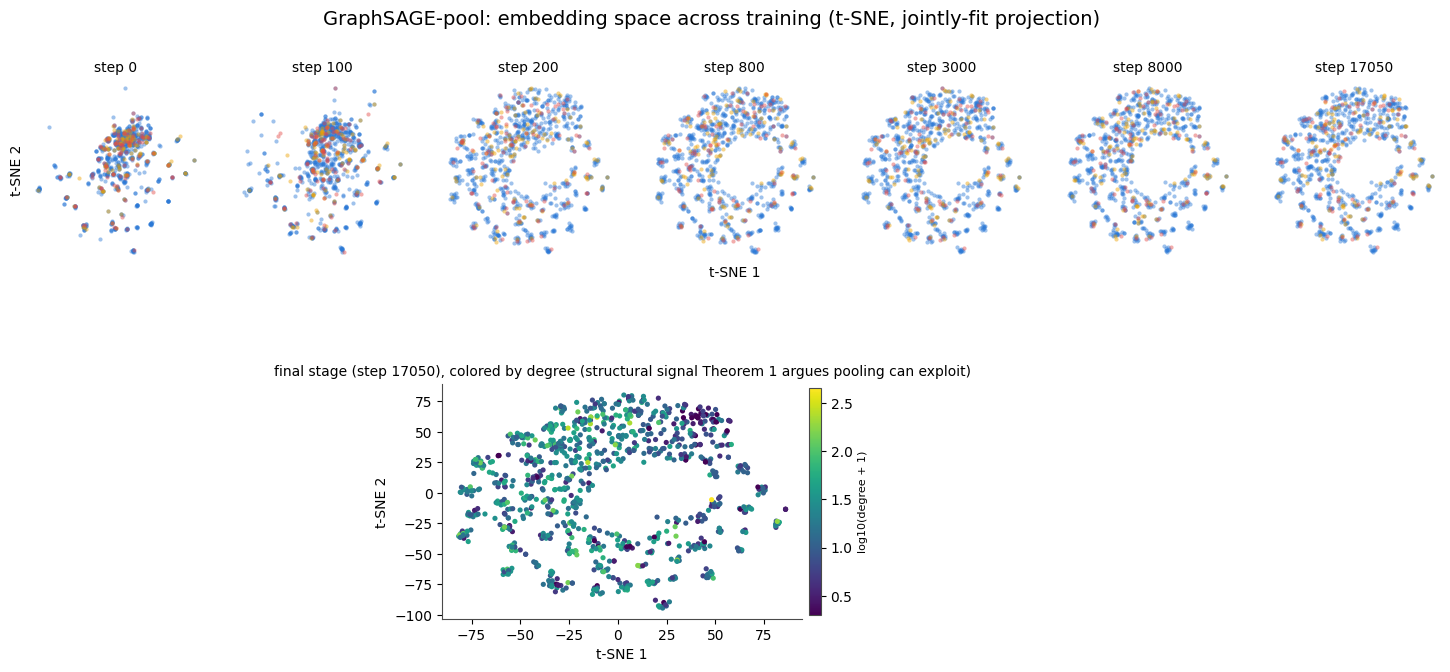

In [8]:
from sklearn.manifold import TSNE

stacked = np.vstack([snapshot_embeddings[step] for step in SNAPSHOT_STEPS])
tsne_joint = TSNE(n_components=2, perplexity=30, init="pca", random_state=123, n_iter=1000)
stacked_2d = tsne_joint.fit_transform(stacked)

n_each = len(sub_ids)
tsne_coords = {step: stacked_2d[i * n_each:(i + 1) * n_each] for i, step in enumerate(SNAPSHOT_STEPS)}

plotting.plot_stage_sheet(
    tsne_coords, SNAPSHOT_STEPS, split_colors, sub_split,
    f"{EMBED_MODEL_NAME}: embedding space across training (t-SNE, jointly-fit projection)", "t-SNE 1", "t-SNE 2",
    sub_degree=sub_degree,
    save_path=os.path.join(RESULTS, "ppi_embedding_tsne.png"));

**Reading the progression.** Both projections tell a consistent story: at
step 0 almost everything collapses into one dense
blob, since the untrained aggregator weights don't yet separate structurally
different nodes. Under t-SNE in particular, the cluster structure visible at
the final step is already largely in place by step 200, three orders of
magnitude fewer gradient steps than the full ~17,050-step epoch, after
which training mostly refines relative distances and density rather than
discovering new cluster structure. That is consistent with Section 4.3 of
the paper, which reports diminishing returns from additional training and
sampling once the aggregators have enough signal to separate neighborhoods.


### 8.3 K- and sample-size sensitivity (Section 4.3)

Figure 2B itself is drawn on citation data specifically, out of scope here
(see README.md), but `scripts/sensitivity_ppi_experiments.py` runs the same
two checks on PPI: `graphsage_mean`, supervised -- K ∈ {1, 2, 3} (samples_2
and samples_3 control this -- see that script's docstring) at fixed
S1=25/S2=10, and separately neighborhood sample size S1=S2=S ∈
{5, 10, 25, 50, 75} at fixed K=2 -- everything else at the architecture
defaults. An earlier scaled run used `--k_only`, skipping the
neighborhood-sample-size half to fit the time budget; a later pass ran it
to completion (see §7 above for the updated timing).

Section 4.3's own claim has two halves for each dimension -- an accuracy
gain *and* a runtime cost -- so both charts below plot F1 (left axis)
against seconds/iteration (right axis) in one panel, instead of showing
only the accuracy half.

,K,samples,test_f1_micro,sec_per_iter
0,1,"[25, 0, 0]",0.47230,0.31831
1,2,"[25, 10, 0]",0.58459,NaN
2,3,"[25, 10, 10]",0.57464,0.70217


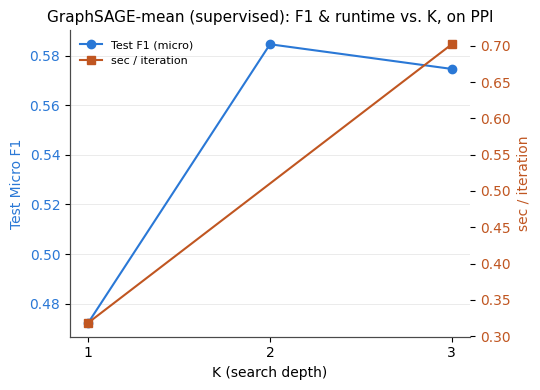

,sample_size,test_f1_micro,sec_per_iter
0,5,0.53605,0.35466
1,10,0.57361,0.36507
2,25,0.59258,0.43512
3,50,0.62415,0.61635
4,75,0.64017,0.82606


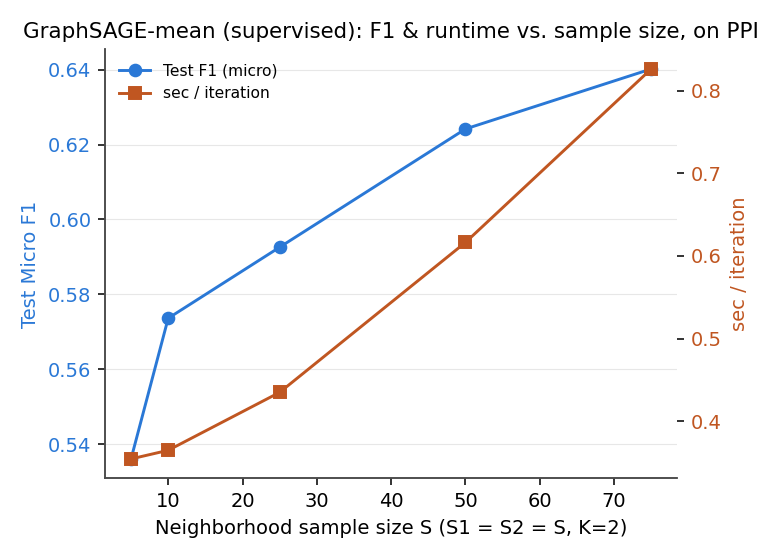

In [9]:
sensitivity_path = os.path.join(RESULTS, "sensitivity_ppi.json")
if not os.path.exists(sensitivity_path):
    print("results/sensitivity_ppi.json not found -- run "
          "scripts/sensitivity_ppi_experiments.py first to populate this plot.")
else:
    with open(sensitivity_path) as fp:
        sensitivity_results = json.load(fp)

    k_rows = sensitivity_results.get("K_sweep", [])
    if k_rows:
        k_df = pd.DataFrame(k_rows).sort_values("K")
        display(k_df[["K", "samples", "test_f1_micro", "sec_per_iter"]])
        plotting.plot_k_sensitivity(k_df, save_path=os.path.join(RESULTS, "ppi_k_sensitivity.png"))

    ss_rows = sensitivity_results.get("sample_size_sweep", [])
    if not ss_rows:
        print("sample_size_sweep is empty -- the scaled run used --k_only, "
              "skipping this half. Run scripts/sensitivity_ppi_experiments.py "
              "(without --k_only) to populate it.")
    else:
        ss_df = pd.DataFrame(ss_rows).sort_values("sample_size")
        display(ss_df)
        plotting.plot_sample_size_sensitivity(ss_df, save_path=os.path.join(RESULTS, "ppi_sample_size_sensitivity.png"))

## 9. Theoretical analysis (overview)

The paper proves (Theorem 1, Appendix E) that, assuming every node has
distinct features, Algorithm 1 can approximate a node's **clustering
coefficient** (the fraction of closed triangles in its 1-hop neighborhood) to
arbitrary precision, using the *pooling* aggregator with $K=4$ iterations:

$$\forall \epsilon>0\ \ \exists\, \Theta^* \text{ s.t., after } K=4 \text{ iterations: } \quad |z_v - c_v| < \epsilon,\ \ \forall v\in V$$

where $c_v$ is the clustering coefficient of node $v$. The proof idea (Lemmas
1–3) is that, if node features are sufficiently distinct, a pooling
aggregator with ≥2 hidden layers can learn to map every node to a unique
**one-hot indicator vector** within its neighborhood — effectively "counting"
nodes and connections in the neighborhood, similar to how the
Weisfeiler-Lehman test iteratively refines node labels.

Empirically (Figure 3 of the paper), progressively replacing real features
with Gaussian noise, `GraphSAGE-pool` retains modest performance by exploiting
*only* graph structure, while `GraphSAGE-GCN` degrades faster — consistent
with the pooling aggregator's expressive capacity used in the proof of
Theorem 1. §9.1 below actually runs this check on PPI, rather than just
describing the paper's own citation-data version of it.

### 9.1 Reproducing Figure 3's noise-robustness check, on PPI

Figure 3 itself is drawn on the citation data specifically, which is out of
scope for this PPI-only reproduction -- but the same kind of check can be run
on PPI: `scripts/noise_robustness_ppi_experiments.py` progressively replaces
a fraction of PPI nodes' feature vectors with Gaussian noise (matching each
feature dimension's real mean/std), retrains `GraphSAGE-GCN` and
`GraphSAGE-pool` from scratch at each noise level (not just evaluated with
noisy test-time inputs on a clean-trained model -- the claim under test is
what the aggregator can *learn* when features are uninformative throughout
training), and re-fits the era-matched raw-features baseline for comparison.
See that script's docstring for the exact noise-injection procedure (a
modeling choice, since the paper doesn't specify one for Figure 3 itself).

```powershell
.venv\Scripts\python.exe scripts\noise_robustness_ppi_experiments.py
```


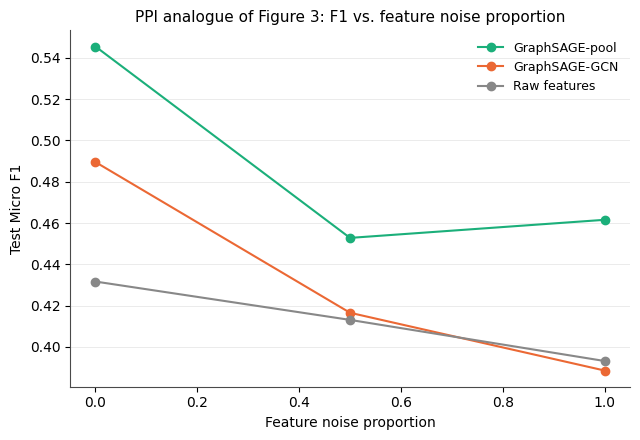

In [10]:
noise_results_path = os.path.join(RESULTS, "noise_robustness_ppi.json")
if not os.path.exists(noise_results_path):
    print("results/noise_robustness_ppi.json not found -- run "
          "scripts/noise_robustness_ppi_experiments.py first (see the cell above) "
          "to populate this plot.")
else:
    with open(noise_results_path) as fp:
        noise_results = json.load(fp)
    plotting.plot_noise_robustness(noise_results, save_path=os.path.join(RESULTS, "ppi_noise_robustness.png"))

## 10. Conclusions

- The reproduced baselines (Random, Raw features) and the 4 GraphSAGE
  variants (GCN, mean, LSTM, pool) on PPI, both supervised and unsupervised,
  reproduce the **qualitative ordering** reported in the paper:
  GraphSAGE-* ≫ Raw features > Random, with GCN consistently the weakest of
  the 4 variants and LSTM/pool the strongest, and supervised consistently
  ≥ unsupervised. This ordering survived the scale-down to a 2-hour local
  budget described in §7 — a smaller experimental budget, not a different
  algorithm.
- Numerical differences from the paper are expected, due to:
  - a **reduced hyperparameter grid**: 2 learning rates × "small" size only,
    not Appendix C's full 3 × {small, big} grid;
  - only **2 seeds** (123, 124) rather than a fuller multi-seed study, and
    only for 5 epochs (except seed=123, which reused the genuine 10-epoch
    default run);
  - TensorFlow version (1.15 here vs. the original ~1.x from 2017) remains
    an unaddressed source of drift. The scikit-learn `SGDClassifier`
    baselines/eval (`scripts/baseline_ppi.py`, `scripts/eval_unsupervised.py`)
    explicitly set `ERA_MATCHED_SGD_PARAMS = dict(max_iter=5, tol=None)`
    to reproduce the paper-era fixed-5-epoch default, rather than relying on
    the installed scikit-learn version's current default (`max_iter=1000`
    with `tol`-based early stopping);
  - different hardware (the paper used 4× Titan X Pascal GPUs; here a
    single RTX 2060).
- §4.3 (K-sensitivity and neighborhood-sample-size sensitivity) and Figure 3
  (feature-noise robustness) are backed by real, if similarly scaled-down,
  PPI runs (§8.3 and §9.1): K=2 clearly beats K=1 (0.585 vs. 0.472 F1, K=3
  not exceeding it at 0.575); F1 also rises monotonically with sample size,
  from 0.536 at S=5 to 0.640 at S=75, but at a steadily growing runtime cost
  (0.35 to 0.83 sec/iteration) -- the same accuracy-for-cost tradeoff the
  paper's own Figure 2B shows on citation data; and GraphSAGE-pool visibly
  retains more of its advantage over GCN and the raw-features baseline as
  features are replaced with noise than GCN does — all qualitatively
  consistent with the paper despite the reduced budget.